# 🏍️ Driving Risk Score Pipeline
**Two-Wheeler IMU-based Driving Behaviour Classification**

| Detail | Value |
|--------|-------|
| Models | XGBoost \| LSTM \| GRU \| Transformer |
| Data | 2,349,158 rows × 7 columns |
| Features | x_acc, y_acc, z_acc, x_gyro, y_gyro, z_gyro, rating |
| Labels | 1=Very Safe, 2=Safe, 3=Moderate, 4=Risky, 5=Very Risky |

---
## 0. Imports & Configuration

In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import time
import warnings
import logging
from pathlib import Path

# ─── Numeric / Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, cohen_kappa_score,
    mean_absolute_error
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight

# ─── Tree-based ──────────────────────────────────────────────────────────────
import xgboost as xgb
from xgboost import XGBClassifier

# ─── Deep Learning ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("✅ All imports successful.")

✅ All imports successful.


In [2]:
CFG = dict(
    data_path      = "final_driving_dataset.csv",   # ← update to your actual path
    output_dir     = "outputs",
    seed           = 42,
    # Windowing
    window_size    = 100,                 # 100 samples ≈ 1 s at 100 Hz
    stride         = 50,                  # 50% overlap
    # ML
    test_size      = 0.2,
    val_size       = 0.1,
    # Deep Learning
    batch_size     = 512,
    dl_epochs      = 30,
    lr             = 1e-3,
    hidden_dim     = 128,
    num_layers     = 2,
    dropout        = 0.3,
    # Transformer
    nhead          = 4,
    dim_feedforward= 256,
    # Device
    device         = "cuda",
)

Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

print(f"🖥️  Device : {CFG['device']}")
print(f"📁 Output : {CFG['output_dir']}/")

🖥️  Device : cuda
📁 Output : outputs/


---
## 1. Data Loading & EDA

In [3]:
def _make_demo(cols):
    """Generate synthetic demo data that mirrors real distribution."""
    log.warning("Data file not found – generating synthetic demo data (50 000 rows).")
    n = 50_000
    np.random.seed(42)
    ratings = np.random.choice([1,2,3,4,5], size=n, p=[0.25,0.30,0.20,0.15,0.10])
    scale = ratings / 3.0
    data = {
        "x_acc"  : np.random.randn(n) * scale,
        "y_acc"  : np.random.randn(n) * 2 * scale,
        "z_acc"  : 9.8 + np.random.randn(n) * 0.5 * scale,
        "x_gyro" : np.random.randn(n) * 5 * scale,
        "y_gyro" : np.random.randn(n) * 4 * scale,
        "z_gyro" : np.random.randn(n) * 6 * scale,
        "rating" : ratings.astype(float),
    }
    return pd.DataFrame(data)


def load_data(path: str) -> pd.DataFrame:
    """Load CSV, validate columns, return clean DataFrame."""
    log.info(f"Loading data from {path}")
    cols = ["x_acc","y_acc","z_acc","x_gyro","y_gyro","z_gyro","rating"]
    df = pd.read_csv(path, usecols=cols) if os.path.exists(path) else _make_demo(cols)
    log.info(f"Shape: {df.shape}  |  Rating distribution:\n{df['rating'].value_counts().sort_index()}")
    return df


df = load_data(CFG["data_path"])
print(f"\nDataFrame shape: {df.shape}")
df.head()


DataFrame shape: (2349158, 7)


,x_acc,y_acc,z_acc,x_gyro,y_gyro,z_gyro,rating
0,-0.79173,-4.23709,9.16870,-4.71483,6.08045,12.31348,1.0
1,-0.44716,2.18525,10.64028,-21.07940,5.18784,4.70720,1.0
2,-1.50957,-2.00219,8.74278,17.42121,1.83863,12.03883,1.0
3,-0.76301,-0.42532,9.33620,1.31222,1.78523,5.42052,1.0
4,-0.18395,-1.60259,9.29313,-21.75076,0.30898,-4.25326,1.0


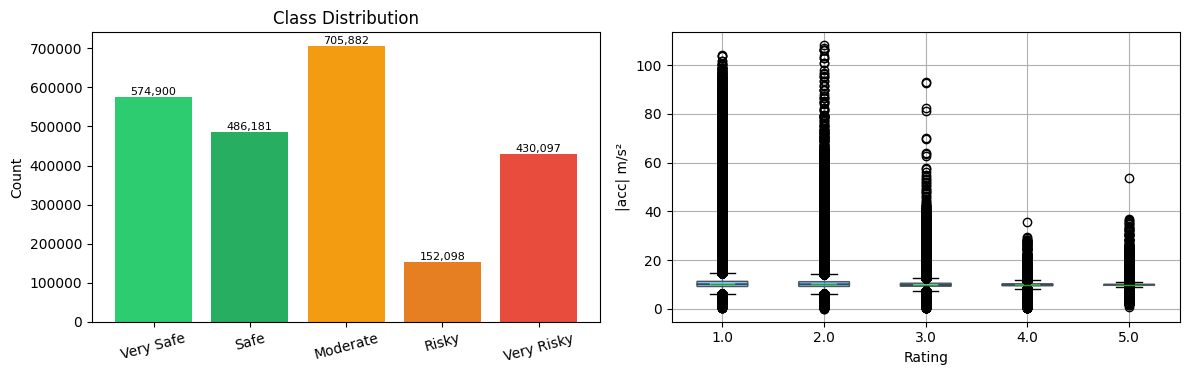

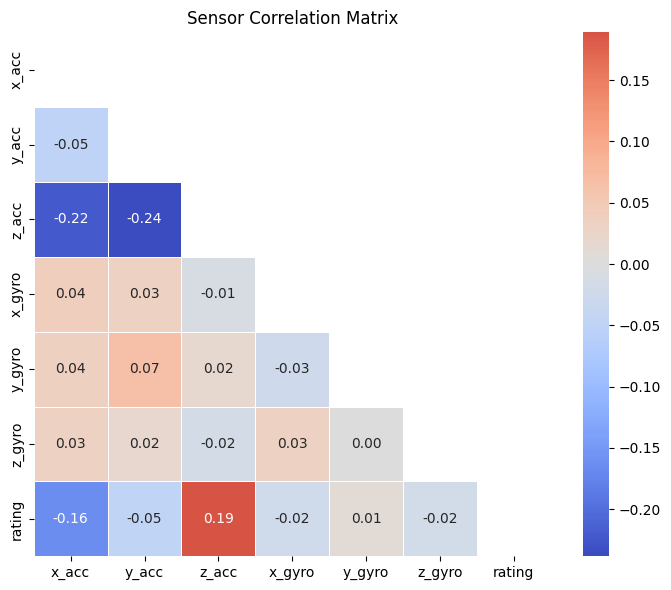

In [4]:
def eda_plots(df: pd.DataFrame, out_dir: str):
    """Save & display EDA figures."""
    log.info("Generating EDA plots …")
    sensor_cols = [c for c in df.columns if c != "rating"]

    # 1. Rating distribution + accelerometer magnitude boxplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = {1:"Very Safe",2:"Safe",3:"Moderate",4:"Risky",5:"Very Risky"}
    vc = df["rating"].value_counts().sort_index()
    axes[0].bar([labels[k] for k in vc.index], vc.values,
                color=["#2ecc71","#27ae60","#f39c12","#e67e22","#e74c3c"])
    axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=15)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():,.0f}", (p.get_x()+p.get_width()/2, p.get_height()),
                         ha="center", va="bottom", fontsize=8)

    axes[1].set_title("Accelerometer Magnitude by Rating")
    df["acc_mag"] = np.sqrt(df["x_acc"]**2 + df["y_acc"]**2 + df["z_acc"]**2)
    df.boxplot(column="acc_mag", by="rating", ax=axes[1], notch=True,
               patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.6))
    axes[1].set_xlabel("Rating"); axes[1].set_ylabel("|acc| m/s²")
    axes[1].set_title(""); fig.suptitle("")
    plt.tight_layout()
    fig.savefig(f"{out_dir}/eda_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()

    # 2. Sensor correlation heat-map
    fig, ax = plt.subplots(figsize=(7, 6))
    corr = df[sensor_cols + ["rating"]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, linewidths=0.5)
    ax.set_title("Sensor Correlation Matrix")
    plt.tight_layout()
    fig.savefig(f"{out_dir}/eda_correlation.png", dpi=120, bbox_inches="tight")
    plt.show()
    log.info("EDA plots saved.")


eda_plots(df, CFG["output_dir"])

---
## 2. Feature Engineering (for Traditional ML)

In [5]:
SENSOR_COLS = ["x_acc","y_acc","z_acc","x_gyro","y_gyro","z_gyro"]

def extract_window_features(window: np.ndarray) -> dict:
    """
    Extract 60 statistical features from a (W × 6) window.
    Features: mean, std, min, max, range, rms, iqr, skewness, kurtosis, energy
    plus derived magnitudes for acc and gyro.
    """
    feats = {}
    for i, col in enumerate(SENSOR_COLS):
        x = window[:, i]
        feats[f"{col}_mean"]  = np.mean(x)
        feats[f"{col}_std"]   = np.std(x)
        feats[f"{col}_min"]   = np.min(x)
        feats[f"{col}_max"]   = np.max(x)
        feats[f"{col}_range"] = np.max(x) - np.min(x)
        feats[f"{col}_rms"]   = np.sqrt(np.mean(x**2))
        feats[f"{col}_iqr"]   = np.percentile(x,75) - np.percentile(x,25)
        feats[f"{col}_skew"]  = float(skew(x))
        feats[f"{col}_kurt"]  = float(kurtosis(x))
        feats[f"{col}_energy"]= np.sum(x**2)
    # Derived magnitudes
    acc  = window[:, :3]
    gyro = window[:, 3:]
    acc_mag  = np.sqrt((acc**2).sum(axis=1))
    gyro_mag = np.sqrt((gyro**2).sum(axis=1))
    for name, mag in [("acc_mag", acc_mag), ("gyro_mag", gyro_mag)]:
        feats[f"{name}_mean"]  = np.mean(mag)
        feats[f"{name}_std"]   = np.std(mag)
        feats[f"{name}_max"]   = np.max(mag)
        feats[f"{name}_range"] = np.max(mag) - np.min(mag)
        feats[f"{name}_rms"]   = np.sqrt(np.mean(mag**2))
    return feats


def build_feature_dataset(df: pd.DataFrame, ws: int, stride: int):
    """Slide a window and build feature matrix + labels."""
    log.info(f"Building feature windows  ws={ws}  stride={stride} …")
    data   = df[SENSOR_COLS].values.astype(np.float32)
    labels = df["rating"].values
    rows, y_out = [], []
    for start in range(0, len(data) - ws + 1, stride):
        w = data[start:start+ws]
        rows.append(extract_window_features(w))
        y_out.append(int(np.round(np.mean(labels[start:start+ws]))))
    feat_df = pd.DataFrame(rows)
    y_arr   = np.array(y_out)
    log.info(f"Feature matrix: {feat_df.shape}  |  Labels: {np.unique(y_arr)}")
    return feat_df, y_arr


def build_sequence_dataset(df: pd.DataFrame, ws: int, stride: int):
    """Slide a window and return raw 3-D sequences (N, T, 6)."""
    log.info(f"Building raw sequences  ws={ws}  stride={stride} …")
    data   = df[SENSOR_COLS].values.astype(np.float32)
    labels = df["rating"].values
    X, y = [], []
    for start in range(0, len(data) - ws + 1, stride):
        X.append(data[start:start+ws])
        y.append(int(np.round(np.mean(labels[start:start+ws]))))
    return np.array(X, dtype=np.float32), np.array(y)


print("✅ Feature engineering functions defined.")

✅ Feature engineering functions defined.


---
## 3. Dataset & DataLoader

In [6]:
class SensorDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, T, 6),  y: class indices 0–4
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


print("✅ SensorDataset class defined.")

✅ SensorDataset class defined.


---
## 4. Deep Learning Models

In [7]:
class LSTMClassifier(nn.Module):
    """Stacked Bi-LSTM with attention pooling + residual skip."""
    def __init__(self, input_dim=6, hidden=128, layers=2, dropout=0.3, n_classes=5):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True,
                            dropout=dropout if layers>1 else 0, bidirectional=True)
        self.attn = nn.Linear(hidden*2, 1)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)                        # (B, T, 2H)
        w = torch.softmax(self.attn(out), dim=1)     # (B, T, 1)
        ctx = (w * out).sum(dim=1)                   # (B, 2H)
        return self.head(ctx)


class GRUClassifier(nn.Module):
    """Stacked Bi-GRU with attention pooling."""
    def __init__(self, input_dim=6, hidden=128, layers=2, dropout=0.3, n_classes=5):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, layers, batch_first=True,
                          dropout=dropout if layers>1 else 0, bidirectional=True)
        self.attn = nn.Linear(hidden*2, 1)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        w = torch.softmax(self.attn(out), dim=1)
        ctx = (w * out).sum(dim=1)
        return self.head(ctx)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, L, D)

    def forward(self, x):                              # (B, T, D)
        return self.drop(x + self.pe[:, :x.size(1)])


class TransformerClassifier(nn.Module):
    """
    Encoder-only Transformer for sequence classification.
    Input projection → PE → N × TransformerEncoderLayer → CLS-token pool → MLP head.
    """
    def __init__(self, input_dim=6, d_model=64, nhead=4,
                 dim_ff=256, num_layers=2, dropout=0.3, n_classes=5):
        super().__init__()
        self.proj  = nn.Linear(input_dim, d_model)
        self.pe    = PositionalEncoding(d_model, dropout)
        enc_layer  = nn.TransformerEncoderLayer(d_model, nhead, dim_ff,
                                                dropout, batch_first=True,
                                                norm_first=True)
        self.enc   = nn.TransformerEncoder(enc_layer, num_layers)
        self.head  = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.pe(self.proj(x))        # (B, T, D)
        x = self.enc(x)                  # (B, T, D)
        x = x.mean(dim=1)               # mean-pool over time → (B, D)
        return self.head(x)


print("✅ Model architectures defined: LSTMClassifier, GRUClassifier, TransformerClassifier.")

✅ Model architectures defined: LSTMClassifier, GRUClassifier, TransformerClassifier.


---
## 5. Training Utilities

In [8]:
def get_class_weights(y: np.ndarray, device: str) -> torch.Tensor:
    """Inverse-frequency class weights for imbalanced data."""
    classes = np.unique(y)
    w = compute_class_weight("balanced", classes=classes, y=y)
    return torch.tensor(w, dtype=torch.float32).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += len(y)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return (total_loss/total, correct/total,
            np.array(all_preds), np.array(all_labels))


def train_dl_model(model, train_ds, val_ds, cfg: dict, label: str):
    """Full training loop with early stopping + LR scheduler."""
    device = cfg["device"]
    model  = model.to(device)

    all_y = train_ds.y.numpy()
    cw    = get_class_weights(all_y, device)
    criterion = nn.CrossEntropyLoss(weight=cw)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg["dl_epochs"], eta_min=1e-5)

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"],
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"],
                              shuffle=False, num_workers=0)

    best_val_f1, best_state = 0, None
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    patience, patience_ctr  = 5, 0

    for epoch in range(1, cfg["dl_epochs"]+1):
        t0 = time.time()
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        vl, va, vp, vl_arr = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        val_f1 = f1_score(vl_arr, vp, average="macro", zero_division=0)
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta); history["val_acc"].append(va)

        if epoch % 5 == 0 or epoch == 1:
            log.info(f"[{label}] Epoch {epoch:3d} | "
                     f"TLoss {tl:.4f}  TAcc {ta:.4f} | "
                     f"VLoss {vl:.4f}  VAcc {va:.4f}  VF1 {val_f1:.4f} | "
                     f"{time.time()-t0:.1f}s")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                log.info(f"[{label}] Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    return model, history


print("✅ Training utilities defined.")

✅ Training utilities defined.


---
## 6. Evaluation & Trustworthiness

In [9]:
CLASS_NAMES = ["Very Safe", "Safe", "Moderate", "Risky", "Very Risky"]

def full_evaluation(model_name: str, y_true: np.ndarray, y_pred: np.ndarray,
                    y_prob: np.ndarray | None, out_dir: str) -> dict:
    """
    Compute and return:
      - Accuracy, macro-F1, Cohen's Kappa (ordinal trustworthiness)
      - Mean Absolute Error (ordinal distance)
      - Confusion matrix plot
      - Calibration plot (reliability diagram) if probabilities available
    """
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae   = mean_absolute_error(y_true, y_pred)

    log.info(f"\n{'='*55}\n{model_name}\n{'='*55}")
    log.info(f"  Accuracy : {acc:.4f}")
    log.info(f"  Macro-F1 : {f1:.4f}")
    log.info(f"  QW-Kappa : {kappa:.4f}  (1=perfect, ≥0.8 trustworthy)")
    log.info(f"  MAE      : {mae:.4f}  (ordinal distance)")
    log.info(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix – {model_name}")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout()
    fig.savefig(f"{out_dir}/cm_{model_name.lower().replace(' ','_')}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

    # Calibration (reliability diagram) – one-vs-rest per class
    if y_prob is not None:
        fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
        for cls in range(5):
            prob_cls = y_prob[:, cls]
            binary   = (y_true == cls).astype(int)
            if binary.sum() > 0 and binary.sum() < len(binary):
                frac_pos, mean_pred = calibration_curve(binary, prob_cls, n_bins=10)
                axes[cls].plot(mean_pred, frac_pos, "s-", label="Model")
                axes[cls].plot([0,1],[0,1],"k--", label="Perfect")
            axes[cls].set_title(CLASS_NAMES[cls], fontsize=9)
            axes[cls].set_xlabel("Mean predicted prob")
        axes[0].set_ylabel("Fraction positives")
        fig.suptitle(f"Calibration Curves – {model_name}", fontsize=10)
        plt.tight_layout()
        fig.savefig(f"{out_dir}/calibration_{model_name.lower().replace(' ','_')}.png",
                    dpi=120, bbox_inches="tight")
        plt.show()

    return {"name": model_name, "acc": acc, "f1": f1,
            "kappa": kappa, "mae": mae}


print("✅ Evaluation function defined.")

✅ Evaluation function defined.


---
## 7. Driving Score Computation

In [10]:
def driving_score_from_probs(probs: np.ndarray) -> np.ndarray:
    """
    Convert class probabilities to a 0–100 driving score.
    Score 100 = Very Safe,  Score 0 = Very Risky.

    Formula:
        raw = Σ (class_weight × p_class)  where class_weight ∈ {1,2,3,4,5}
        score = 100 × (5 - raw) / 4        (linear inversion, 0–100)
    """
    weights = np.array([1, 2, 3, 4, 5])            # ordinal weights
    raw     = (probs * weights).sum(axis=1)         # expected rating
    score   = np.clip(100 * (5 - raw) / 4, 0, 100) # invert & scale
    return score


def risk_category(score: float) -> str:
    if score >= 80: return "🟢 Very Safe"
    if score >= 60: return "🟡 Safe"
    if score >= 40: return "🟠 Moderate"
    if score >= 20: return "🔴 Risky"
    return "🔴🔴 Very Risky"


def demo_score_report(model, scaler, seq_X: np.ndarray,
                      device: str, label: str, n_samples=5):
    """Print a sample driving score report for n_samples random windows."""
    model.eval()
    idx = np.random.choice(len(seq_X), n_samples, replace=False)
    X   = torch.tensor(scaler.transform(
              seq_X[idx].reshape(-1, 6)).reshape(n_samples, -1, 6),
              dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = F.softmax(model(X), dim=1).cpu().numpy()
    scores = driving_score_from_probs(probs)
    print(f"\n{'─'*50}")
    print(f"  DRIVING SCORE REPORT  [{label}]")
    print(f"{'─'*50}")
    print(f"  {'Sample':>6}  {'Score':>6}  Category")
    for i, (s, p) in enumerate(zip(scores, probs)):
        print(f"  {i+1:>6}  {s:>5.1f}   {risk_category(s)}   "
              f"probs={np.round(p,2)}")
    print(f"{'─'*50}\n")


print("✅ Driving score functions defined.")

✅ Driving score functions defined.


---
## 8. Comparison & Training Curve Plots

In [11]:
def comparison_plot(results: list, out_dir: str):
    names  = [r["name"]  for r in results]
    accs   = [r["acc"]   for r in results]
    f1s    = [r["f1"]    for r in results]
    kappas = [r["kappa"] for r in results]
    maes   = [r["mae"]   for r in results]

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    metrics = [("Accuracy", accs, "#3498db"),
               ("Macro-F1", f1s, "#2ecc71"),
               ("QW-Kappa", kappas, "#9b59b6"),
               ("MAE (↓)",  maes, "#e74c3c")]

    for ax, (title, vals, color) in zip(axes, metrics):
        bars = ax.bar(x, vals, color=color, alpha=0.8, edgecolor="white")
        ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right")
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylim(0, max(vals)*1.15 + 0.05)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle("Model Comparison – Driving Risk Classification", fontsize=13)
    plt.tight_layout()
    fig.savefig(f"{out_dir}/model_comparison.png", dpi=130, bbox_inches="tight")
    plt.show()
    log.info("Comparison plot saved.")


def training_curves(histories: dict, out_dir: str):
    """Plot loss and accuracy curves for all DL models."""
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for col, (name, hist) in enumerate(histories.items()):
        e = range(1, len(hist["train_loss"])+1)
        axes[0, col].plot(e, hist["train_loss"], label="train")
        axes[0, col].plot(e, hist["val_loss"],   label="val")
        axes[0, col].set_title(f"{name} – Loss"); axes[0, col].legend()
        axes[0, col].set_xlabel("Epoch")

        axes[1, col].plot(e, hist["train_acc"], label="train")
        axes[1, col].plot(e, hist["val_acc"],   label="val")
        axes[1, col].set_title(f"{name} – Accuracy"); axes[1, col].legend()
        axes[1, col].set_xlabel("Epoch")

    plt.tight_layout()
    fig.savefig(f"{out_dir}/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


print("✅ Plotting functions defined.")

✅ Plotting functions defined.


---
## 9. Main Pipeline

### 9.1 Load & EDA

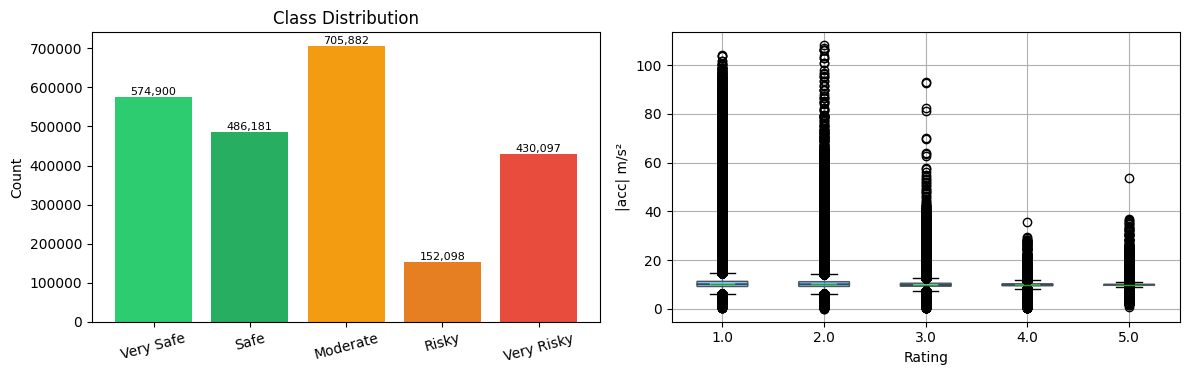

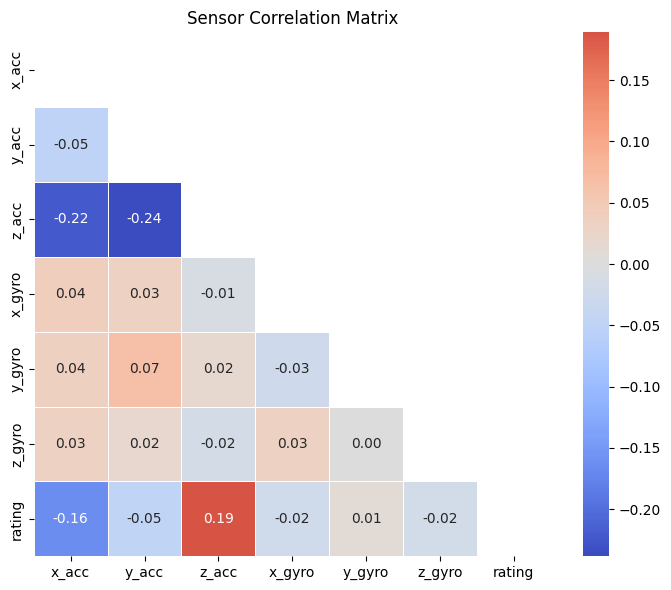

In [12]:
t_start = time.time()
OUT    = CFG["output_dir"]
DEVICE = CFG["device"]
log.info(f"Device: {DEVICE}")

df = load_data(CFG["data_path"])
eda_plots(df, OUT)

# Convert ratings 1-5 → class indices 0-4
df["label"] = (df["rating"] - 1).astype(int)

### 9.2 Feature Matrix for XGBoost

In [13]:
feat_df, y_feat = build_feature_dataset(df, CFG["window_size"], CFG["stride"])
y_feat_idx      = y_feat - 1   # shift to 0-based

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    feat_df.values, y_feat_idx,
    test_size=CFG["test_size"], random_state=CFG["seed"], stratify=y_feat_idx)

scaler_ml = StandardScaler().fit(X_tr_f)
X_tr_f_s  = scaler_ml.transform(X_tr_f)
X_te_f_s  = scaler_ml.transform(X_te_f)

print(f"Train: {X_tr_f_s.shape}  |  Test: {X_te_f_s.shape}")

Train: (37585, 70)  |  Test: (9397, 70)


### 9.3 Train XGBoost

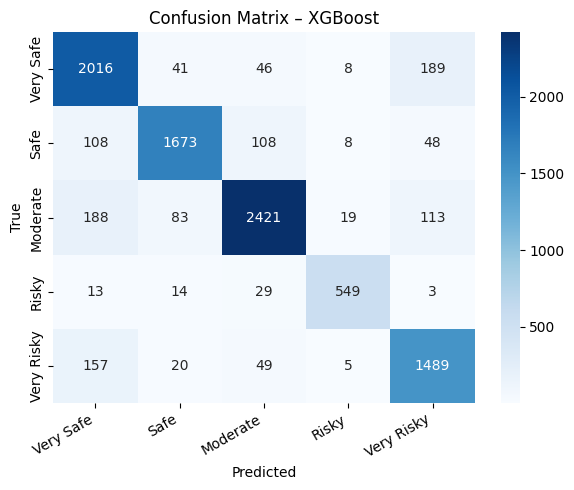

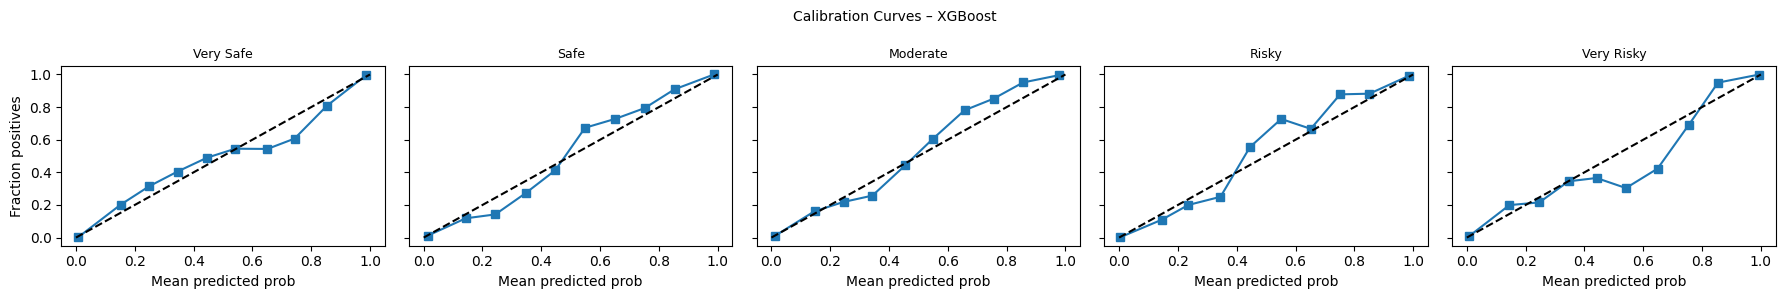

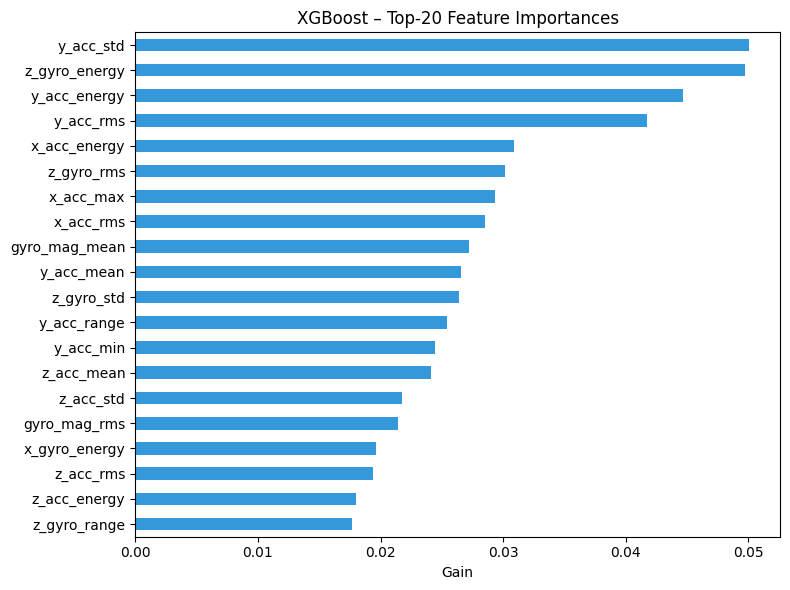

In [14]:
log.info("Training XGBoost …")
cw_dict  = {i: 1.0/np.mean(y_tr_f == i) for i in range(5)}
sample_w = np.array([cw_dict[y] for y in y_tr_f])

xgb_model = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=CFG["seed"], tree_method="hist",
    early_stopping_rounds=20, verbosity=0,
)
xgb_model.fit(
    X_tr_f_s, y_tr_f,
    sample_weight=sample_w,
    eval_set=[(X_te_f_s, y_te_f)],
    verbose=False,
)
xgb_pred = xgb_model.predict(X_te_f_s)
xgb_prob = xgb_model.predict_proba(X_te_f_s)
res_xgb  = full_evaluation("XGBoost", y_te_f, xgb_pred, xgb_prob, OUT)

# Feature importance plot
fig, ax = plt.subplots(figsize=(8, 6))
fi = pd.Series(xgb_model.feature_importances_, index=feat_df.columns)
fi.nlargest(20).sort_values().plot.barh(ax=ax, color="#3498db")
ax.set_title("XGBoost – Top-20 Feature Importances")
ax.set_xlabel("Gain"); plt.tight_layout()
fig.savefig(f"{OUT}/xgb_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

### 9.4 Sequence Data for Deep Learning

In [15]:
seq_X, seq_y = build_sequence_dataset(df, CFG["window_size"], CFG["stride"])
seq_y_idx    = seq_y - 1   # 0-based

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    seq_X, seq_y_idx,
    test_size=CFG["test_size"]+CFG["val_size"],
    random_state=CFG["seed"], stratify=seq_y_idx)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,
    test_size=CFG["test_size"]/(CFG["test_size"]+CFG["val_size"]),
    random_state=CFG["seed"], stratify=y_tmp)

# Scale each feature channel using training statistics
scaler_dl = StandardScaler()
scaler_dl.fit(X_tr.reshape(-1, 6))
def scale_seq(X):
    return scaler_dl.transform(X.reshape(-1,6)).reshape(X.shape)

X_tr_s, X_val_s, X_te_s = scale_seq(X_tr), scale_seq(X_val), scale_seq(X_te)

train_ds    = SensorDataset(X_tr_s,  y_tr)
val_ds      = SensorDataset(X_val_s, y_val)
test_ds     = SensorDataset(X_te_s,  y_te)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Train: 32887  |  Val: 4698  |  Test: 9397


### 9.5 Train LSTM

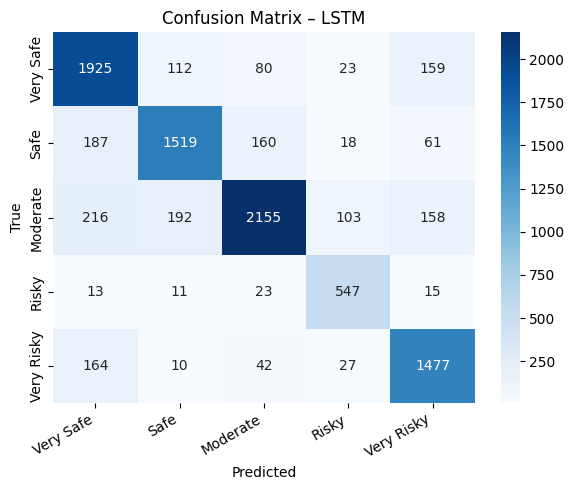

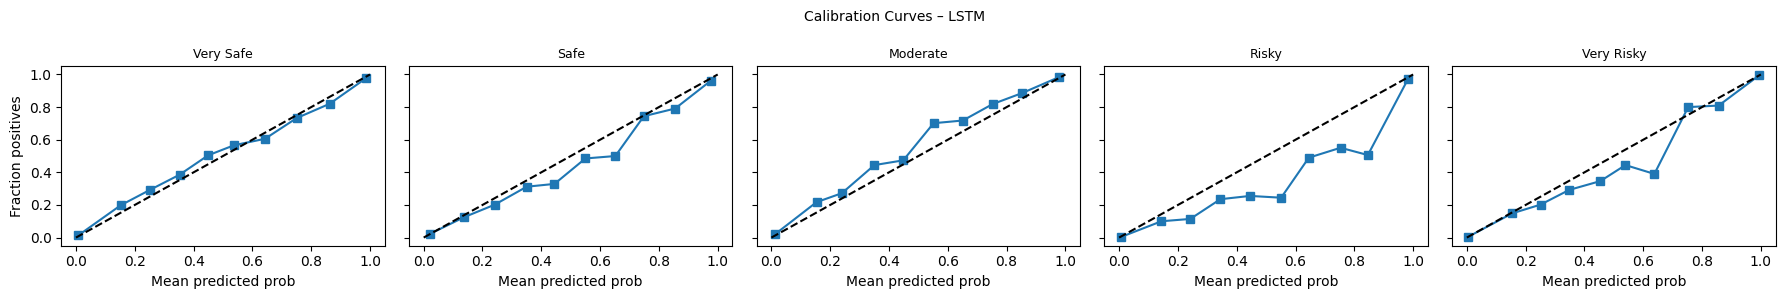

In [16]:
lstm_model = LSTMClassifier(
    input_dim=6, hidden=CFG["hidden_dim"],
    layers=CFG["num_layers"], dropout=CFG["dropout"])
lstm_model, lstm_hist = train_dl_model(lstm_model, train_ds, val_ds, CFG, "LSTM")

cw_loss = nn.CrossEntropyLoss(weight=get_class_weights(y_tr, DEVICE))
_, _, lstm_pred, lstm_true = eval_epoch(lstm_model, test_loader, cw_loss, DEVICE)
lstm_model.eval()
lstm_prob = []
for Xb, _ in test_loader:
    with torch.no_grad():
        lstm_prob.append(F.softmax(lstm_model(Xb.to(DEVICE)), dim=1).cpu().numpy())
lstm_prob = np.vstack(lstm_prob)
res_lstm  = full_evaluation("LSTM", lstm_true, lstm_pred, lstm_prob, OUT)

### 9.6 Train GRU

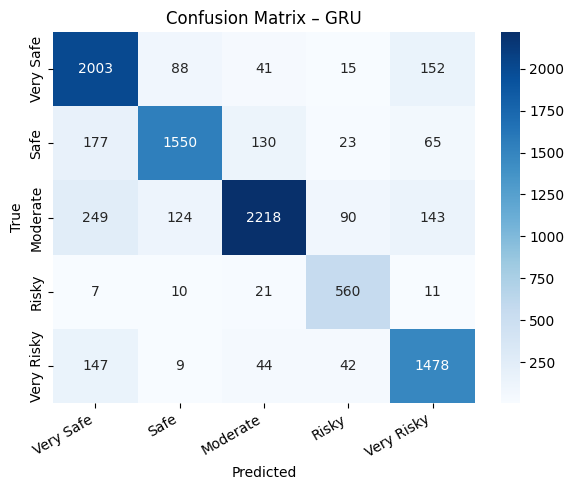

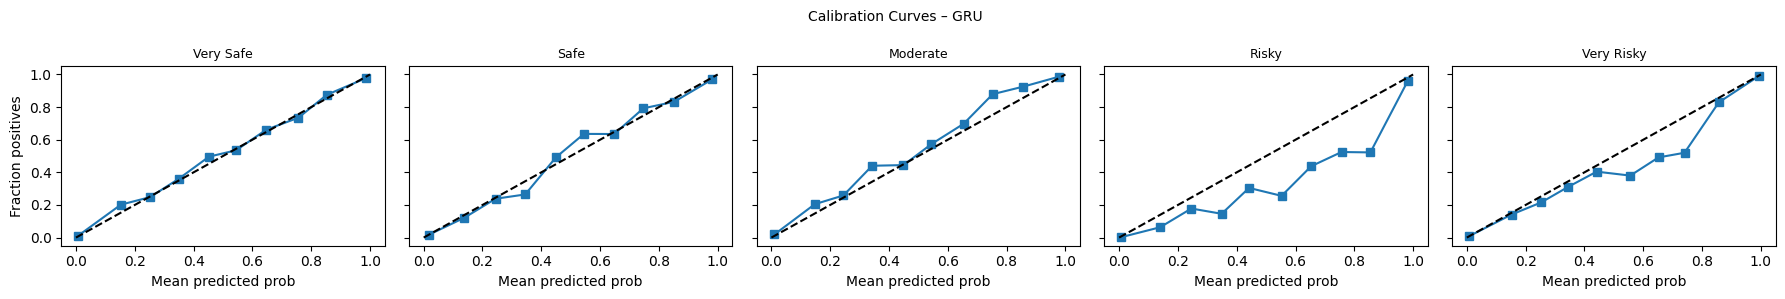

In [17]:
gru_model = GRUClassifier(
    input_dim=6, hidden=CFG["hidden_dim"],
    layers=CFG["num_layers"], dropout=CFG["dropout"])
gru_model, gru_hist = train_dl_model(gru_model, train_ds, val_ds, CFG, "GRU")

_, _, gru_pred, gru_true = eval_epoch(gru_model, test_loader, cw_loss, DEVICE)
gru_model.eval()
gru_prob = []
for Xb, _ in test_loader:
    with torch.no_grad():
        gru_prob.append(F.softmax(gru_model(Xb.to(DEVICE)), dim=1).cpu().numpy())
gru_prob = np.vstack(gru_prob)
res_gru  = full_evaluation("GRU", gru_true, gru_pred, gru_prob, OUT)

### 9.7 Train Transformer

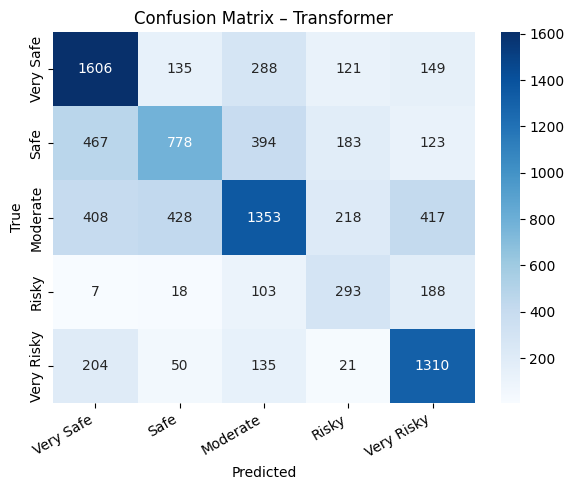

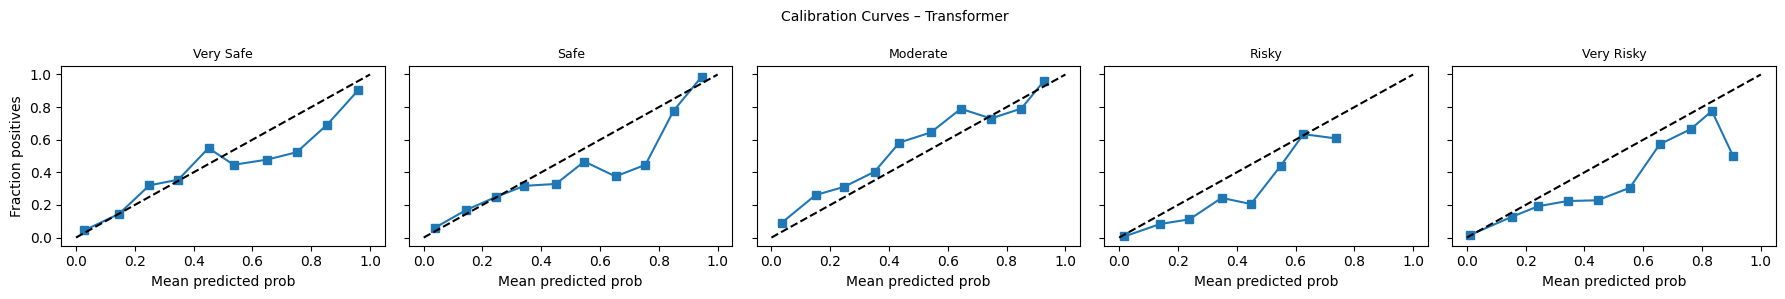

In [18]:
tf_model = TransformerClassifier(
    input_dim=6, d_model=64,
    nhead=CFG["nhead"], dim_ff=CFG["dim_feedforward"],
    num_layers=CFG["num_layers"], dropout=CFG["dropout"])
tf_model, tf_hist = train_dl_model(tf_model, train_ds, val_ds, CFG, "Transformer")

_, _, tf_pred, tf_true = eval_epoch(tf_model, test_loader, cw_loss, DEVICE)
tf_model.eval()
tf_prob = []
for Xb, _ in test_loader:
    with torch.no_grad():
        tf_prob.append(F.softmax(tf_model(Xb.to(DEVICE)), dim=1).cpu().numpy())
tf_prob = np.vstack(tf_prob)
res_tf  = full_evaluation("Transformer", tf_true, tf_pred, tf_prob, OUT)

### 9.8 Training Curves & Model Comparison

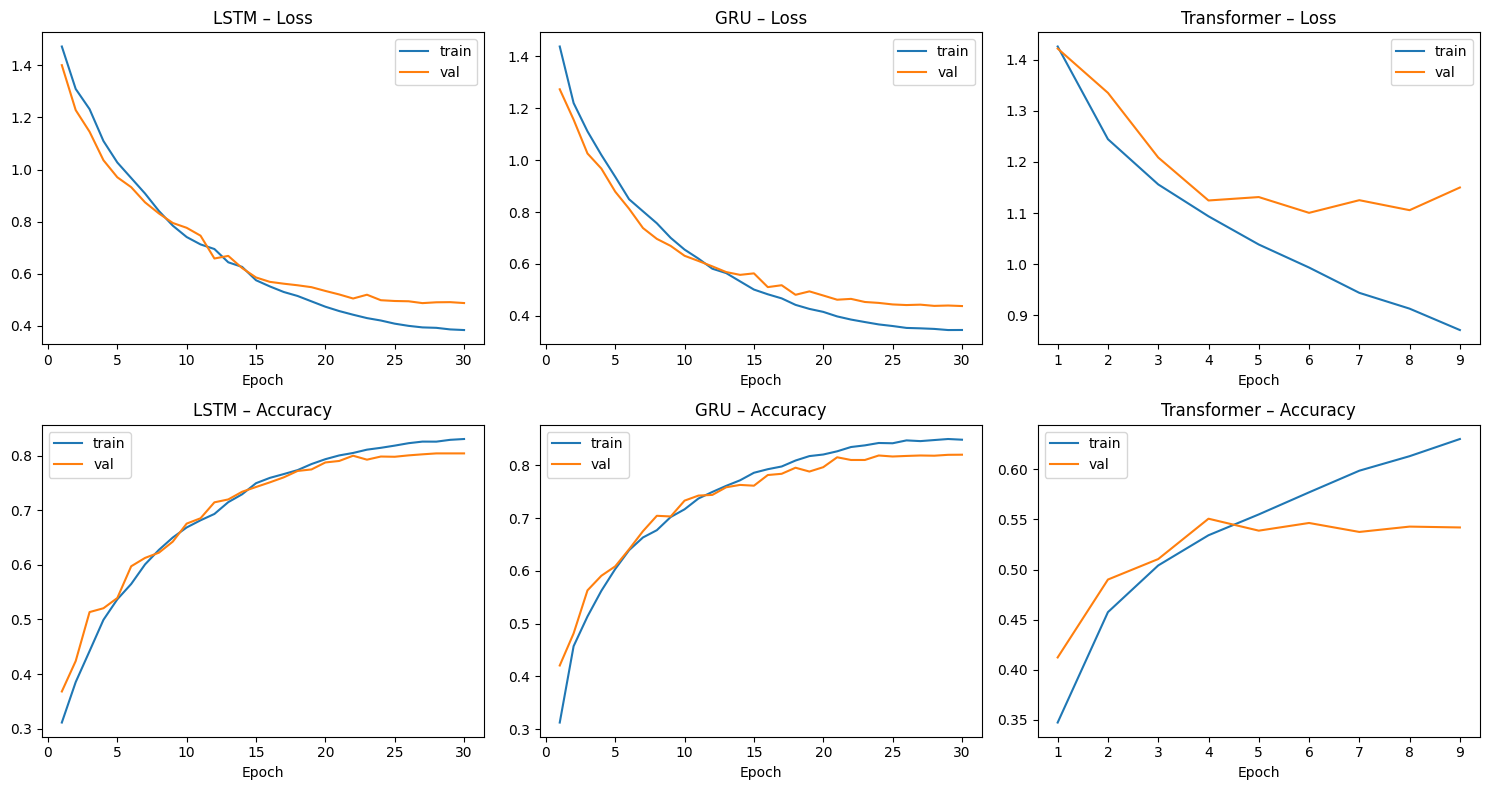

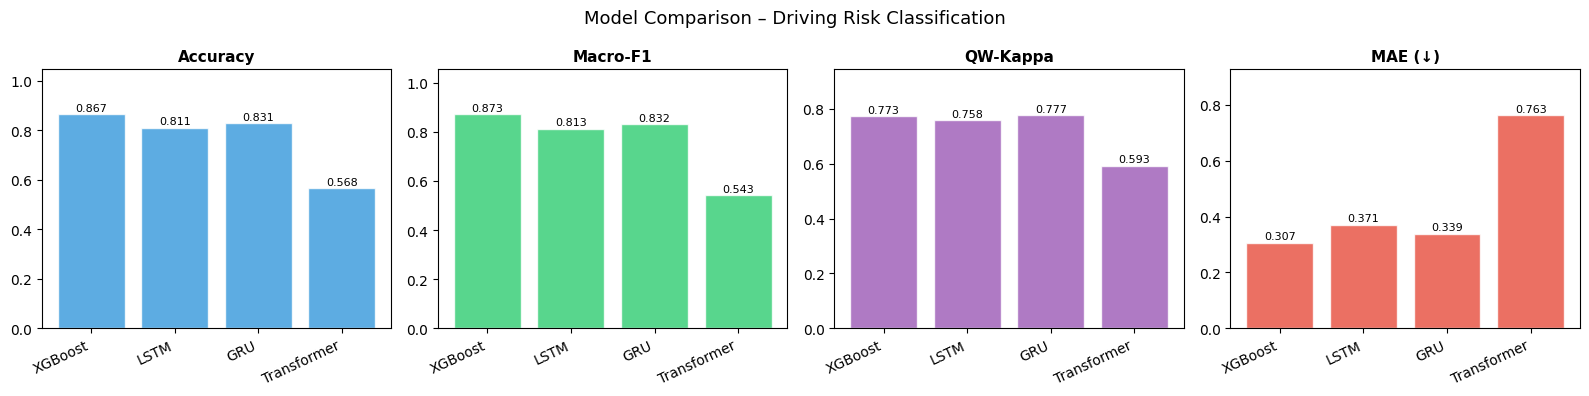

In [19]:
training_curves({"LSTM": lstm_hist, "GRU": gru_hist, "Transformer": tf_hist}, OUT)

all_results = [res_xgb, res_lstm, res_gru, res_tf]
comparison_plot(all_results, OUT)

### 9.9 Sample Driving Score Reports

In [20]:
demo_score_report(lstm_model, scaler_dl, X_te, DEVICE, "LSTM")
demo_score_report(tf_model,   scaler_dl, X_te, DEVICE, "Transformer")


──────────────────────────────────────────────────
  DRIVING SCORE REPORT  [LSTM]
──────────────────────────────────────────────────
  Sample   Score  Category
       1   65.9   🟡 Safe   probs=[0.44 0.11 0.25 0.01 0.18]
       2   55.2   🟠 Moderate   probs=[0.01 0.18 0.8  0.   0.  ]
       3   74.7   🟡 Safe   probs=[0.01 0.97 0.01 0.   0.  ]
       4  100.0   🟢 Very Safe   probs=[1. 0. 0. 0. 0.]
       5   50.7   🟠 Moderate   probs=[0.   0.03 0.97 0.   0.  ]
──────────────────────────────────────────────────


──────────────────────────────────────────────────
  DRIVING SCORE REPORT  [Transformer]
──────────────────────────────────────────────────
  Sample   Score  Category
       1   56.1   🟠 Moderate   probs=[0.13 0.18 0.58 0.01 0.1 ]
       2   19.7   🔴🔴 Very Risky   probs=[0.02 0.11 0.17 0.05 0.65]
       3   66.4   🟡 Safe   probs=[0.28 0.25 0.33 0.13 0.01]
       4   65.2   🟡 Safe   probs=[0.31 0.16 0.44 0.01 0.08]
       5    9.2   🔴🔴 Very Risky   probs=[0.   0.02 0.09 0.13 0.77

### 9.10 Final Summary

In [21]:
print(f"\n{'='*55}")
print("FINAL SUMMARY")
print(f"{'='*55}")
print(f"  {'Model':<15} {'Acc':>8} {'F1':>8} {'Kappa':>8} {'MAE':>8}")
print(f"  {'-'*51}")
for r in all_results:
    print(f"  {r['name']:<15} {r['acc']:>8.4f} {r['f1']:>8.4f} "
          f"{r['kappa']:>8.4f} {r['mae']:>8.4f}")
print(f"\nTotal wall-clock time: {(time.time()-t_start)/60:.1f} min")
print(f"All outputs written to: {OUT}/")


FINAL SUMMARY
  Model                Acc       F1    Kappa      MAE
  ---------------------------------------------------
  XGBoost           0.8671   0.8733   0.7729   0.3068
  LSTM              0.8112   0.8132   0.7582   0.3705
  GRU               0.8310   0.8315   0.7770   0.3392
  Transformer       0.5683   0.5429   0.5928   0.7627

Total wall-clock time: 18.3 min
All outputs written to: outputs/


In [22]:
import joblib
from pathlib import Path

SAVE_DIR = Path(CFG["output_dir"]) / "saved_models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# XGBoost
xgb_model.save_model(SAVE_DIR / "xgboost.ubj")

# PyTorch models
for name, model in [("lstm", lstm_model), ("gru", gru_model), ("transformer", tf_model)]:
    torch.save({
        "model_state_dict" : model.state_dict(),
        "cfg"              : CFG,
    }, SAVE_DIR / f"{name}.pt")

# Scalers
joblib.dump(scaler_ml, SAVE_DIR / "scaler_ml.pkl")
joblib.dump(scaler_dl, SAVE_DIR / "scaler_dl.pkl")

print(f"✅ All models saved to {SAVE_DIR}/")

✅ All models saved to outputs/saved_models/
